In [1]:
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch


sys.path.append("../../../code/sandbox/john/INN")

from soccermap.statsbomb_io import load_events, load_threesixty, load_lineups
from soccermap.expand import build_expanded_dfs
from soccermap.channels import create_14_channels
from soccermap.config import GridSpec

DATA_ROOT = "../../../data/leverkusen_data"
MATCH_ID = "3895302" 

events = load_events(DATA_ROOT, MATCH_ID)
threesixty = load_threesixty(DATA_ROOT, MATCH_ID)
lineups = load_lineups(DATA_ROOT, MATCH_ID)

m = build_expanded_dfs(events, threesixty, lineups)
expanded_df = m.expanded_df


In [2]:
actors = expanded_df[expanded_df["actor"] == True].copy()
leverkusen_passes = actors[
    (actors["event_type"] == "Pass")
    & (actors["team"] == "Bayer Leverkusen")
    & (actors["end_location"].notna())
]

random_pass = leverkusen_passes.sample(15).iloc[5]
event_id = random_pass["event_id"]
print(f"Event: {event_id}, minute {random_pass['minute']}:{random_pass['second']}")

grid = GridSpec()
chans = create_14_channels(expanded_df, event_id, grid)
print(f"Channels shape: {chans.shape}")


Event: 9035b7a7-f461-4a66-a2d4-558c620733e7, minute 17:10
Channels shape: (14, 120, 80)


In [3]:
CHANNEL_NAMES = [
    "0: Teammate loc", "1: Opponent loc", "2: Teammate vx", "3: Teammate vy",
    "4: Opponent vx", "5: Opponent vy", "6: Dist to ball", "7: Dist to goal",
    "8: sin(goal,ball)", "9: cos(goal,ball)", "10: Angle to goal",
    "11: sin(pass,mate)", "12: cos(pass,mate)", "13: Visibility",
]

def visualize_channel(chans, ch=0, figsize=(12, 8)):
    pitch = Pitch(pitch_type='statsbomb', line_zorder=2, pitch_color='green', line_color='white')
    fig, ax = pitch.draw(figsize=figsize)

    # chans[ch] is (L=120, W=80), need to overlay on the pitch
    # statsbomb pitch: x in [0,120], y in [0,80]
    im = ax.imshow(
        chans[ch].T,
        extent=[0, 120, 0, 80],
        origin='lower',
        aspect='auto',
        cmap='viridis',
        alpha=0.7,
        zorder=1,
    )
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_title(CHANNEL_NAMES[ch], fontsize=14)
    plt.tight_layout()
    plt.show()


In [36]:
import sys, os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mplsoccer import Pitch

PROJECT_ROOT = "/Users/jpark/workspace/02_2026_winter/00_sta490/Player-decision-simulation"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "code", "sandbox", "john", "INN"))

from soccermap.statsbomb_io import load_events, load_threesixty, load_lineups
from soccermap.expand import build_expanded_dfs
from soccermap.dataset import PassDataset
from soccermap.model import SoccerMapWithPlayerEmbed, SoccerMapConfig
from soccermap.viz import _extract_scene, _to_img_yx

# ---- Load match data ----
DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "leverkusen_data")
MATCH_ID = "3895348"
CKPT_PATH = os.path.join(PROJECT_ROOT, "checkpoints", "pass_selection_embed4.pt")

events = load_events(DATA_ROOT, MATCH_ID)
threesixty = load_threesixty(DATA_ROOT, MATCH_ID)
lineups = load_lineups(DATA_ROOT, MATCH_ID)
m = build_expanded_dfs(events, threesixty, lineups)

ds = PassDataset(m.expanded_df, compute_velocities=False, only_passes=True, team_filter="Bayer Leverkusen")
print(f"Total pass samples in match: {len(ds)}")

# ---- Load checkpoint & model ----
ckpt = torch.load(CKPT_PATH, map_location="cpu")
player_id_mapping = ckpt["player_id_mapping"]
num_players = ckpt["num_players"]
embed_dim = ckpt["embed_dim"]

model = SoccerMapWithPlayerEmbed(
    num_players=num_players,
    embed_dim=embed_dim,
    cfg=SoccerMapConfig(),
)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Model loaded — {num_players} players, embed_dim={embed_dim}")


Total pass samples in match: 676
Model loaded — 29 players, embed_dim=8


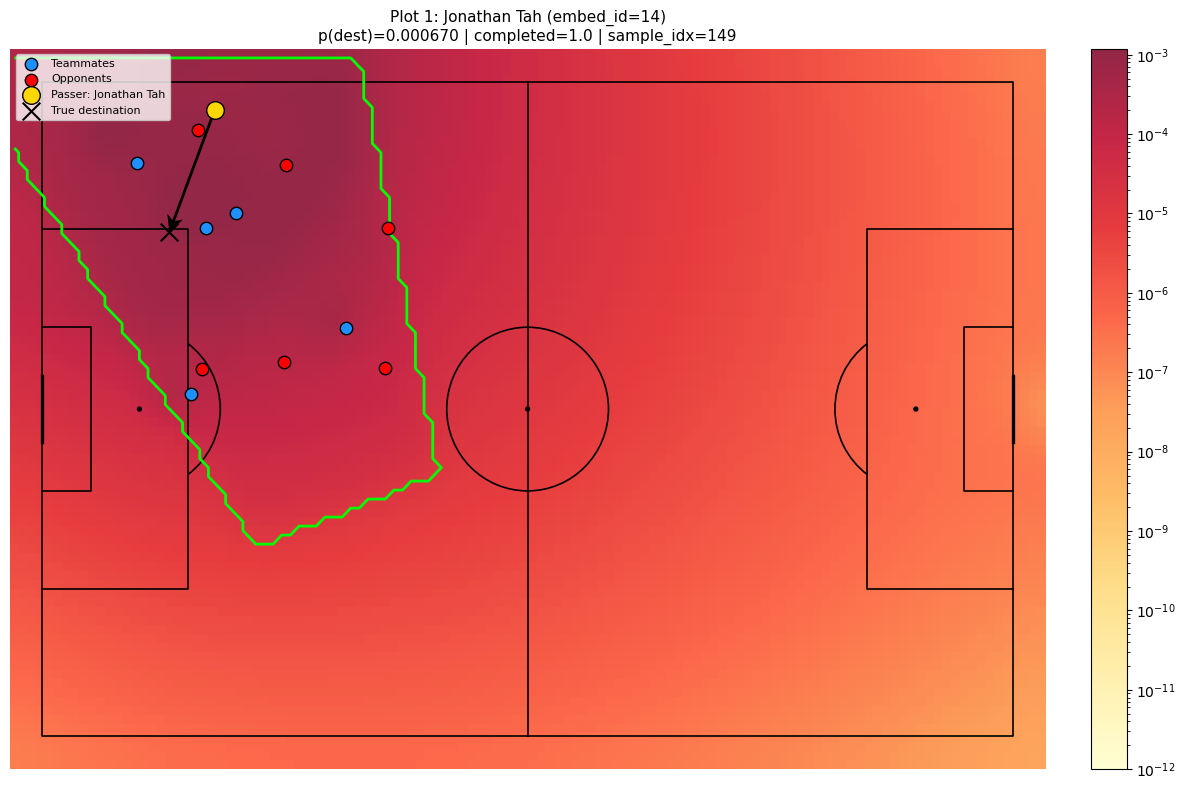

In [37]:
IDX = random.randint(0, len(ds)-1)
sample = ds[IDX]

# ---- Forward pass with actual passer's embedding ----
actor_name = sample.actor_player_name
actor_id = player_id_mapping.get(actor_name, 0)

with torch.no_grad():
    x = sample.channels.unsqueeze(0)                          # (1, 14, 120, 80)
    actor_ids = torch.tensor([actor_id], dtype=torch.long)
    logits = model(x, actor_ids)                               # (1, 1, 120, 80)

    flat = logits.view(1, -1)
    prob_flat = torch.softmax(flat, dim=1)[0]                  # (9600,)
    L, W = logits.shape[2], logits.shape[3]
    prob_LW = prob_flat.view(L, W).cpu().numpy()
    p_dest = float(prob_flat[sample.dest_index].item())

# ---- Extract scene info ----
passer_xy, dest_xy, completed, atk_xy, dfn_xy = _extract_scene(m.expanded_df, sample.event_id)

# ---- Visibility mask (channel 13) ----
vis_mask = sample.channels[13].numpy()   # (120, 80), 1=visible, 0=not

# ---- Plot ----
pitch = Pitch(pitch_type="statsbomb", line_color="black", linewidth=1.2)
fig, ax = pitch.draw(figsize=(12, 8))

# probability field
img = _to_img_yx(prob_LW)
eps = 1e-12
img_plot = np.clip(img, eps, None)
vmax = max(float(np.quantile(img_plot, 0.995)), eps * 10)
norm = mcolors.LogNorm(vmin=eps, vmax=vmax)
im = ax.imshow(img_plot, extent=pitch.extent, origin="upper", aspect="auto",
               cmap="YlOrRd", norm=norm, alpha=0.85, interpolation="nearest")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# visibility mask boundary (masking zone)
vis_img = _to_img_yx(vis_mask)  # (80, 120)
ax.contour(vis_img, levels=[0.5], colors="lime", linewidths=2,
           extent=pitch.extent, origin="upper")

# players
if atk_xy.size:
    pitch.scatter(atk_xy[:, 0], atk_xy[:, 1], s=80, ax=ax, color="dodgerblue",
                  edgecolors="black", zorder=5, label="Teammates")
if dfn_xy.size:
    pitch.scatter(dfn_xy[:, 0], dfn_xy[:, 1], s=80, ax=ax, color="red",
                  edgecolors="black", zorder=5, label="Opponents")

# passer + pass arrow + destination
if passer_xy:
    pitch.scatter([passer_xy[0]], [passer_xy[1]], s=160, ax=ax, color="gold",
                  edgecolors="black", zorder=6, label=f"Passer: {actor_name}")
if dest_xy:
    pitch.scatter([dest_xy[0]], [dest_xy[1]], s=160, marker="x", ax=ax,
                  color="black", zorder=6, label="True destination")
if passer_xy and dest_xy:
    pitch.arrows(passer_xy[0], passer_xy[1], dest_xy[0], dest_xy[1],
                 ax=ax, width=2, headwidth=6, headlength=6, color="black")

ax.set_title(f"Plot 1: {actor_name} (embed_id={actor_id})\n"
             f"p(dest)={p_dest:.6f} | completed={completed} | sample_idx={IDX}",
             fontsize=11)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


In [38]:
ckpt["player_id_mapping"]['Granit Xhaka']

10

Original passer: Jonathan Tah (id=14)
Swapped player:  Granit Xhaka (id=10)


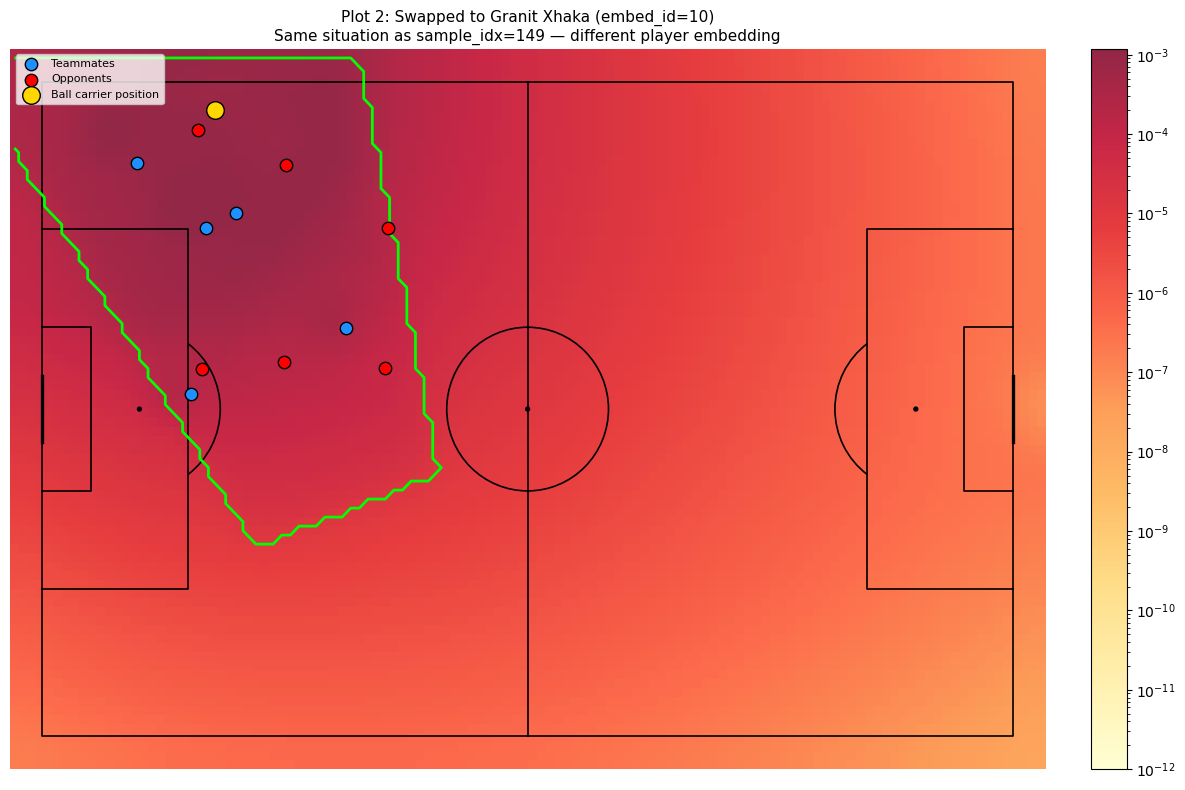

In [39]:
# ---- Pick a different teammate from the same event ----
ev_rows = m.expanded_df[m.expanded_df["event_id"] == sample.event_id]
teammates = ev_rows[(ev_rows["actor"] == False) & (ev_rows["teammate"] == True)]

# Find a teammate that exists in the player_id_mapping
swap_name = None
swap_id = 0
for _, row in teammates.iterrows():
    name = row.get("player_name")
    if name and name in player_id_mapping and name != actor_name:
        swap_name = name
        swap_id = player_id_mapping[name]
        break

if swap_name is None:
    # fallback: pick any other player from the mapping
    for name, pid in player_id_mapping.items():
        if name != actor_name:
            swap_name, swap_id = name, pid
            break

swap_name = 'Granit Xhaka'
swap_id = 10

print(f"Original passer: {actor_name} (id={actor_id})")
print(f"Swapped player:  {swap_name} (id={swap_id})")


# ---- Forward pass with swapped embedding ----
with torch.no_grad():
    swap_ids = torch.tensor([swap_id], dtype=torch.long)
    logits2 = model(x, swap_ids)                               # same channels, different embedding

    flat2 = logits2.view(1, -1)
    prob_flat2 = torch.softmax(flat2, dim=1)[0]
    prob_LW2 = prob_flat2.view(L, W).cpu().numpy()

# ---- Plot ----
pitch = Pitch(pitch_type="statsbomb", line_color="black", linewidth=1.2)
fig, ax = pitch.draw(figsize=(12, 8))

# probability field
img2 = _to_img_yx(prob_LW2)
img2_plot = np.clip(img2, eps, None)
vmax2 = max(float(np.quantile(img2_plot, 0.995)), eps * 10)
norm2 = mcolors.LogNorm(vmin=eps, vmax=vmax2)
im2 = ax.imshow(img2_plot, extent=pitch.extent, origin="upper", aspect="auto",
                cmap="YlOrRd", norm=norm2, alpha=0.85, interpolation="nearest")
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# visibility mask boundary
ax.contour(vis_img, levels=[0.5], colors="lime", linewidths=2,
           extent=pitch.extent, origin="upper")

# players (same positions — no passer/arrow since this is hypothetical)
if atk_xy.size:
    pitch.scatter(atk_xy[:, 0], atk_xy[:, 1], s=80, ax=ax, color="dodgerblue",
                  edgecolors="black", zorder=5, label="Teammates")
if dfn_xy.size:
    pitch.scatter(dfn_xy[:, 0], dfn_xy[:, 1], s=80, ax=ax, color="red",
                  edgecolors="black", zorder=5, label="Opponents")
if passer_xy:
    pitch.scatter([passer_xy[0]], [passer_xy[1]], s=160, ax=ax, color="gold",
                  edgecolors="black", zorder=6, label="Ball carrier position")

ax.set_title(f"Plot 2: Swapped to {swap_name} (embed_id={swap_id})\n"
             f"Same situation as sample_idx={IDX} — different player embedding",
             fontsize=11)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


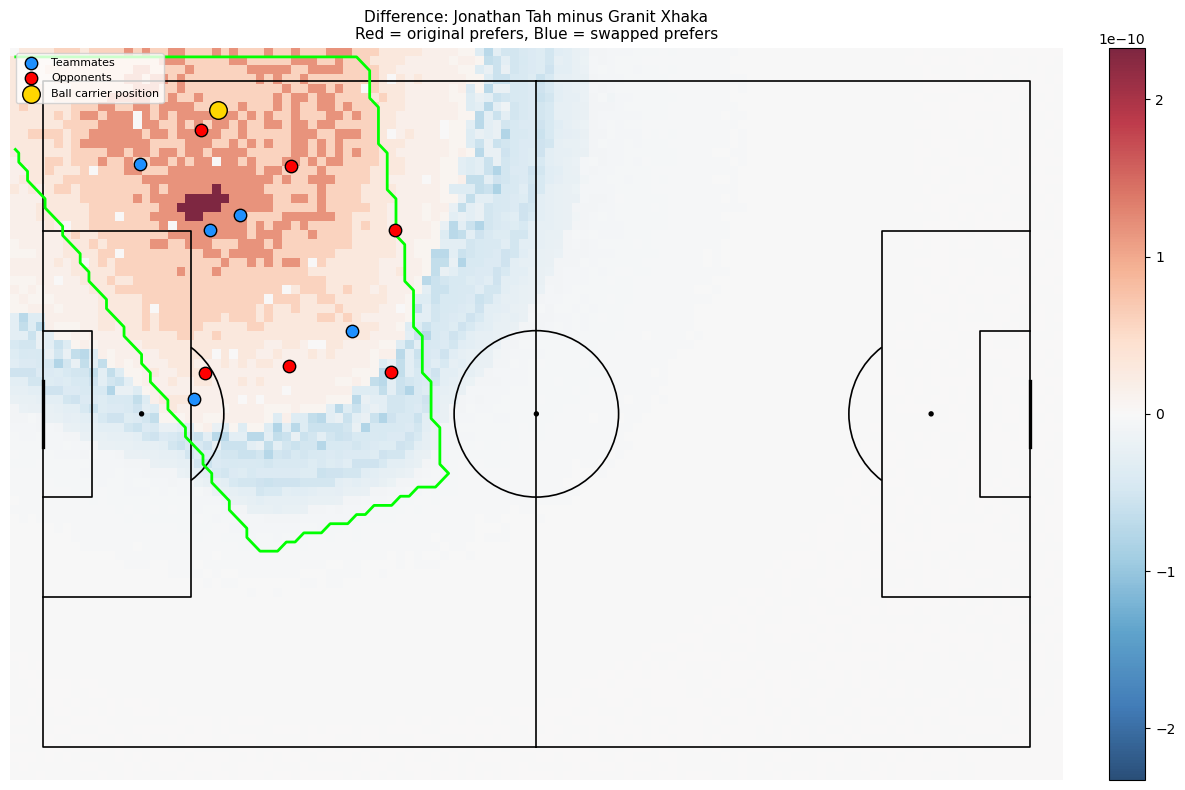

In [40]:
# ---- Difference plot ----
difference_plot = img_plot - img2_plot

pitch = Pitch(pitch_type="statsbomb", line_color="black", linewidth=1.2)
fig, ax = pitch.draw(figsize=(12, 8))

vmax = max(abs(difference_plot.min()), abs(difference_plot.max()))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(difference_plot, extent=pitch.extent, origin="upper", aspect="auto",
               cmap="RdBu_r", norm=norm, alpha=0.85, interpolation="nearest")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.contour(vis_img, levels=[0.5], colors="lime", linewidths=2,
           extent=pitch.extent, origin="upper")

if atk_xy.size:
    pitch.scatter(atk_xy[:, 0], atk_xy[:, 1], s=80, ax=ax, color="dodgerblue",
                  edgecolors="black", zorder=5, label="Teammates")
if dfn_xy.size:
    pitch.scatter(dfn_xy[:, 0], dfn_xy[:, 1], s=80, ax=ax, color="red",
                  edgecolors="black", zorder=5, label="Opponents")
if passer_xy:
    pitch.scatter([passer_xy[0]], [passer_xy[1]], s=160, ax=ax, color="gold",
                  edgecolors="black", zorder=6, label="Ball carrier position")

ax.set_title(f"Difference: {actor_name} minus {swap_name}\n"
             f"Red = original prefers, Blue = swapped prefers", fontsize=11)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


In [41]:
# # Load the holdout match
# holdout_id = "3895348"
# events = load_events(DATA_ROOT, holdout_id)
# threesixty = load_threesixty(DATA_ROOT, holdout_id)
# lineups = load_lineups(DATA_ROOT, holdout_id)
# m = build_expanded_dfs(events, threesixty, lineups)

# from soccermap.dataset import PassDataset
# test_ds = PassDataset(m.expanded_df, compute_velocities=True, only_passes=True)

# # Load checkpoint
# player_id_mapping = ckpt["player_id_mapping"]

# from soccermap.model import SoccerMapWithPlayerEmbed, SoccerMapConfig, pass_selection_kl_loss

# model = SoccerMapWithPlayerEmbed(
#     num_players=ckpt["num_players"],
#     embed_dim=ckpt["embed_dim"],
#     cfg=SoccerMapConfig(),
# )
# model.load_state_dict(ckpt["model_state"])
# model.eval()

# # Evaluate
# test_total = 0.0
# test_n = 0
# with torch.no_grad():
#     for i in range(len(test_ds)):
#         sample = test_ds[i]
#         channels = sample.channels.unsqueeze(0)
#         dest = torch.tensor([sample.dest_index], dtype=torch.long)
#         actor_id = torch.tensor([player_id_mapping.get(sample.actor_player_name, 0)], dtype=torch.long)

#         logits = model(channels, actor_id)
#         loss = pass_selection_kl_loss(logits, dest)

#         test_total += float(loss.item())
#         test_n += 1

# print(f"Test loss (holdout match {holdout_id}): {test_total / test_n:.4f}  ({test_n} samples)")


/var/folders/vd/j_d7xxb56hg064_h1h3mkqt80000gn/T/ipykernel_95884/992437540.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd").copy()


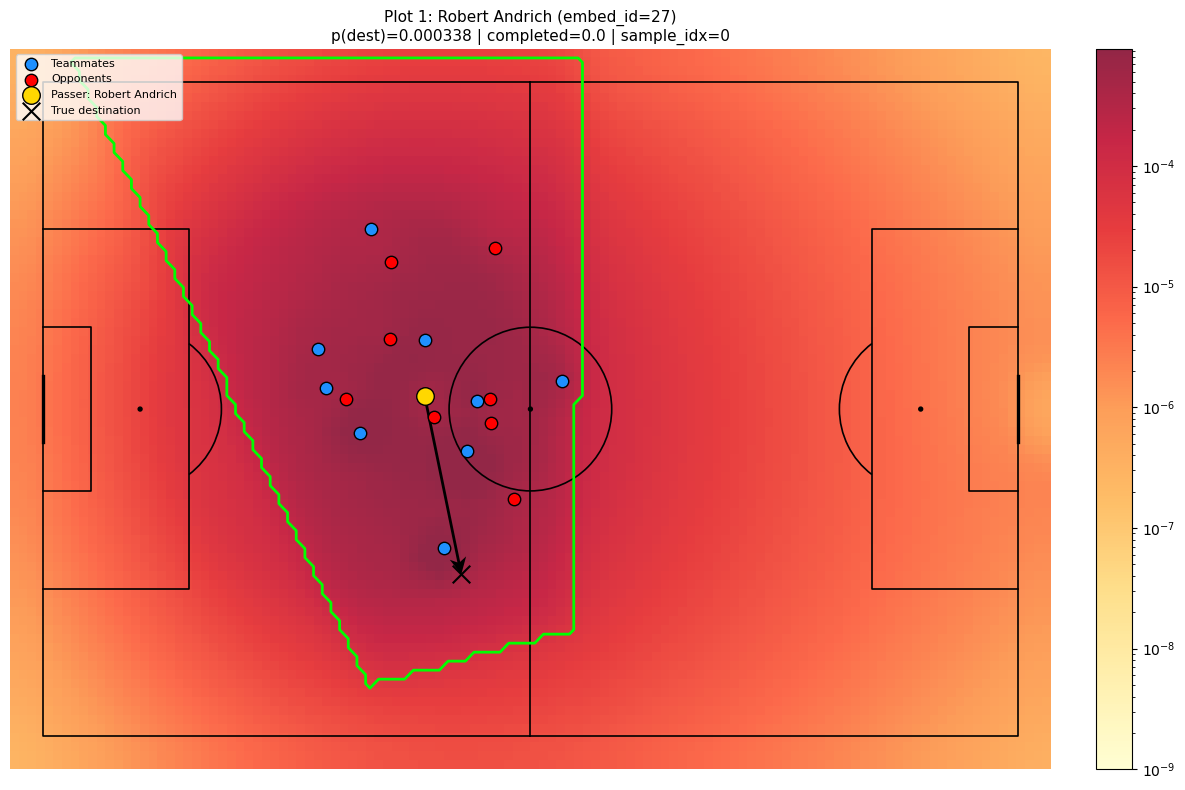

In [42]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mplsoccer import Pitch

SAMPLE_IDX = 0
sample = ds[SAMPLE_IDX]

# ---- Forward pass with actual passer's embedding ----
actor_name = sample.actor_player_name
actor_id = player_id_mapping.get(actor_name, 0)

with torch.no_grad():
    x = sample.channels.unsqueeze(0)                          # (1, 14, 120, 80)
    actor_ids = torch.tensor([actor_id], dtype=torch.long)
    logits = model(x, actor_ids)                              # (1, 1, 120, 80)

    flat = logits.view(1, -1)
    prob_flat = torch.softmax(flat, dim=1)[0]                 # (9600,)
    L, W = logits.shape[2], logits.shape[3]
    prob_LW = prob_flat.view(L, W).cpu().numpy()
    p_dest = float(prob_flat[sample.dest_index].item())

# ---- Extract scene info ----
passer_xy, dest_xy, completed, atk_xy, dfn_xy = _extract_scene(
    m.expanded_df, sample.event_id
)

# ---- Visibility mask (channel 13) ----
vis_mask = sample.channels[13].cpu().numpy()   # (120, 80), 1=visible, 0=not

# ---- Plot ----
pitch = Pitch(pitch_type="statsbomb", line_color="black", linewidth=1.2)
fig, ax = pitch.draw(figsize=(12, 8))

# ---- Probability field ----
img = _to_img_yx(prob_LW)

eps = 1e-12
white_threshold = 1e-9   # increase to 1e-8 or 1e-7 if you want more white
img_plot = np.clip(img, eps, None)

vmax = max(float(np.quantile(img_plot, 0.995)), white_threshold * 10)

cmap = cm.get_cmap("YlOrRd").copy()
cmap.set_under("white")   # values below vmin will be pure white

norm = mcolors.LogNorm(vmin=white_threshold, vmax=vmax)

im = ax.imshow(
    img_plot,
    extent=pitch.extent,
    origin="upper",
    aspect="auto",
    cmap=cmap,
    norm=norm,
    alpha=0.85,
    interpolation="nearest"
)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ---- Visibility mask boundary ----
vis_img = _to_img_yx(vis_mask)   # (80, 120)
ax.contour(
    vis_img,
    levels=[0.5],
    colors="lime",
    linewidths=2,
    extent=pitch.extent,
    origin="upper"
)

# ---- Players ----
if atk_xy.size:
    pitch.scatter(
        atk_xy[:, 0], atk_xy[:, 1],
        s=80,
        ax=ax,
        color="dodgerblue",
        edgecolors="black",
        zorder=5,
        label="Teammates"
    )

if dfn_xy.size:
    pitch.scatter(
        dfn_xy[:, 0], dfn_xy[:, 1],
        s=80,
        ax=ax,
        color="red",
        edgecolors="black",
        zorder=5,
        label="Opponents"
    )

# ---- Passer + destination + arrow ----
if passer_xy:
    pitch.scatter(
        [passer_xy[0]], [passer_xy[1]],
        s=160,
        ax=ax,
        color="gold",
        edgecolors="black",
        zorder=6,
        label=f"Passer: {actor_name}"
    )

if dest_xy:
    pitch.scatter(
        [dest_xy[0]], [dest_xy[1]],
        s=160,
        marker="x",
        ax=ax,
        color="black",
        zorder=6,
        label="True destination"
    )

if passer_xy and dest_xy:
    pitch.arrows(
        passer_xy[0], passer_xy[1],
        dest_xy[0], dest_xy[1],
        ax=ax,
        width=2,
        headwidth=6,
        headlength=6,
        color="black"
    )

ax.set_title(
    f"Plot 1: {actor_name} (embed_id={actor_id})\n"
    f"p(dest)={p_dest:.6f} | completed={completed} | sample_idx={SAMPLE_IDX}",
    fontsize=11
)

ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()